## Thematic Analysis and Clustering of Greek Supreme Court Decisions

### Objective

This notebook explores the thematic structure of Greek Supreme Court decisions from the **GreekLegalSum** dataset using unsupervised machine learning techniques. Clustering algorithms are applied to identify meaningful groups of documents and reveal patterns across different legal topics. The analysis focuses on `case_category` and `case_tags`, which represent the primary legal area and the more specific legal issues associated with each case.


**Dataset available at __[huggingface](https://huggingface.co/datasets/DominusTea/GreekLegalSum/viewer/default/train?row=0&views%5B%5D=train)__**

**Imports**

In [2]:
#imports
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gzip
import shutil
from gensim.models import KeyedVectors
from matplotlib import colormaps
import seaborn as sns
from gensim.models import KeyedVectors
from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib.ticker import PercentFormatter

### Exploratory Data Analysis ###

We will examine the case_category and case_tags variables from the Hugging Face DataFrame.
First, we perform a univariate analysis on each variable separately to understand their individual distributions and identify the most common categories and tags.
Next, we conduct a bivariate analysis to explore potential patterns, associations, and relationships between case_category and case_tags.

The analysis is text-oriented. The dataset contains 4 useful columns. First a univariate analysis will be performed on each variable separately to understand their individual distributions and identify the most common categories and tags. Next is a bivariate analysis to explore potential patterns, associations, and relationships between case_category and case_tags, text and summary.

In [3]:
df = pd.read_csv("hf://datasets/DominusTea/GreekLegalSum/hugginface_dataset.csv")

#### Univariate Analysis

In [4]:
unique = df["case_category"].nunique()
print(f"Number of unique categories in case_category: {unique}")

Number of unique categories in case_category: 399


In [5]:
# lolipop char using pyplot and seborn for styling
top_categories = (df["case_category"].value_counts().head(20))

def loliplot(top_categories, title):
    fig, ax = plt.subplots(figsize=(15, 7))
    
    colors = colormaps["viridis"](np.linspace(0.15, 0.9, len(top_categories)))
    
    x_positions = np.arange(len(top_categories))
    
    #  stems
    ax.vlines(
        x=x_positions,
        ymin=0,
        ymax=top_categories.values,
        color=colors,
        linewidth=3,
        alpha=0.75
    )
    
    #  heads
    ax.scatter(
        x=x_positions,
        y=top_categories.values,
        color=colors,
        s=110,
        edgecolor="white",
        linewidth=1.2,
        zorder=3
    )
    
    # Count labels above the markers
    for x, count in zip(x_positions, top_categories.values):
        ax.text(
            x,
            count + top_categories.max() * 0.02,
            f"{count:,}",
            ha="center",
            va="bottom",
            fontsize=9
        )
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        top_categories.index,
        rotation=55,
        ha="right"
    )
    
    ax.set_title(
        f"Top 20 Case {title}",
        fontsize=16,
        loc="left"
    )
    ax.set_xlabel("")
    ax.set_ylabel("Number of cases")
    
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.grid(axis="x", visible=False)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    ax.set_ylim(0, top_categories.max() * 1.12)
    
    plt.tight_layout()
    plt.show()

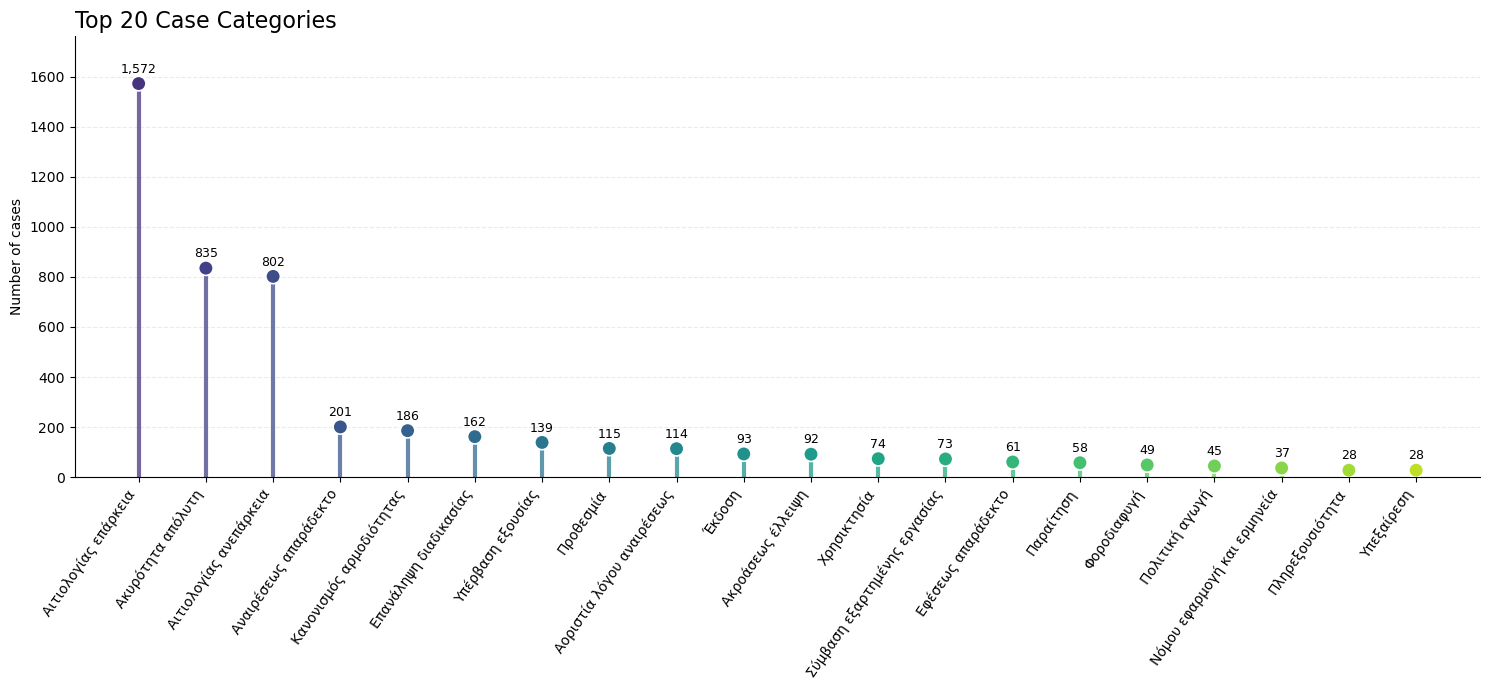

In [6]:
loliplot(top_categories, "Categories")

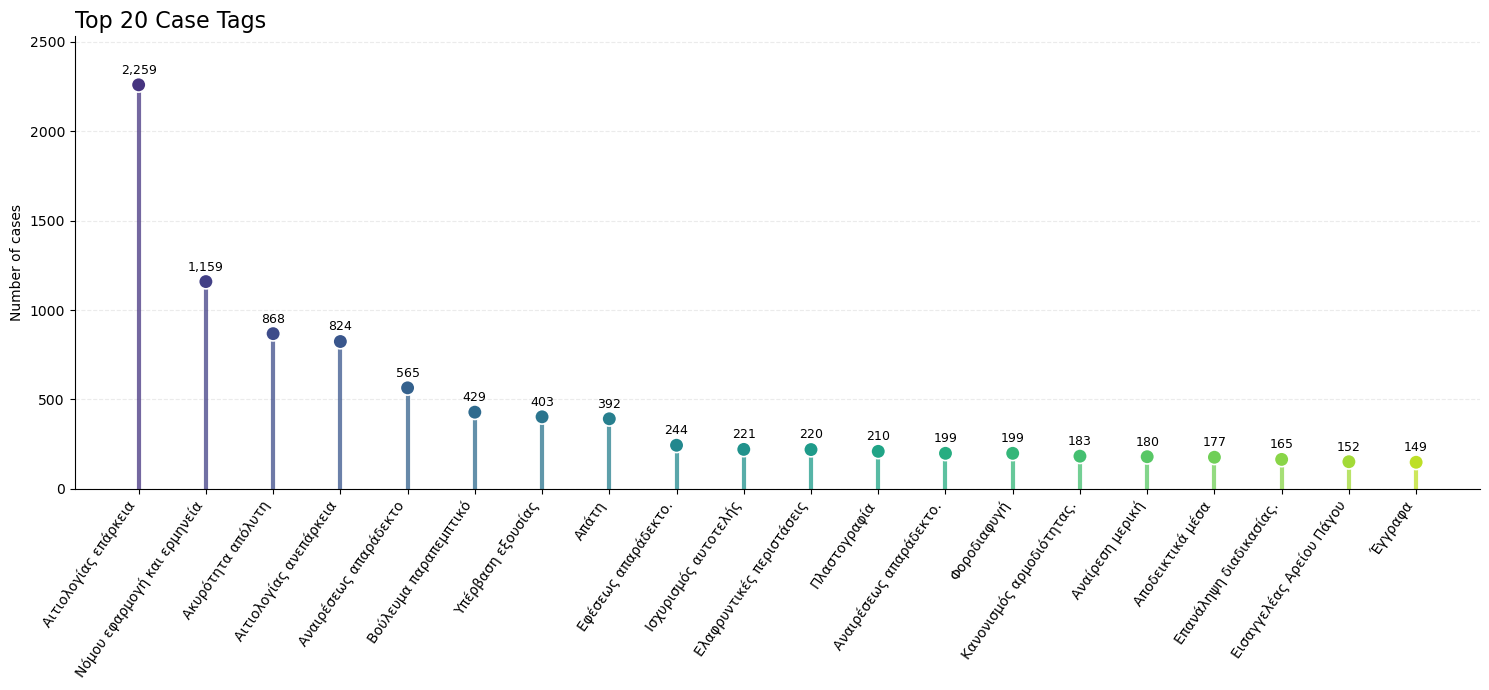

In [7]:
# Handling string objects and splitting into separate words
df['tag_list'] = df['case_tags'].fillna('').apply(lambda x: [tag.strip() for tag in x.split(',') if tag.strip()])

tag_exploded = df.explode('tag_list')

tag_counts = tag_exploded['tag_list'].value_counts()

tags_top_categories = (tag_counts.head(20))

loliplot(tags_top_categories, "Tags")

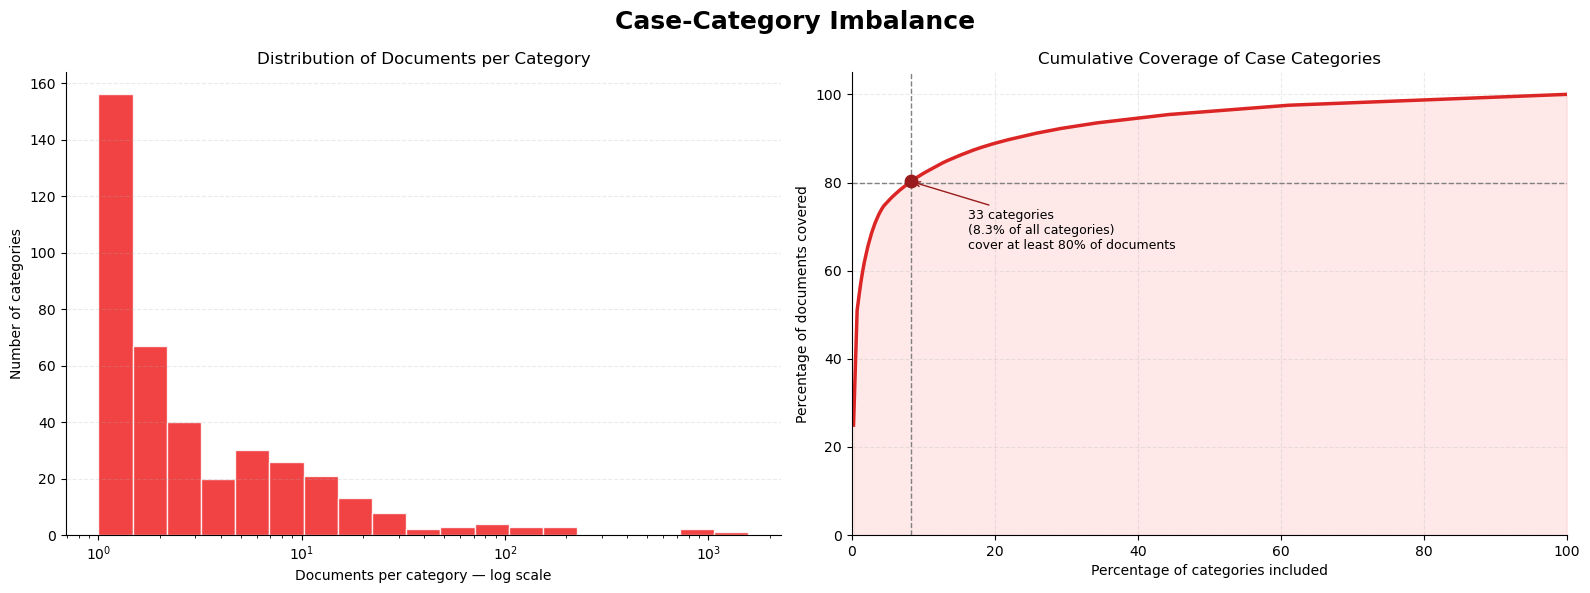

In [8]:
plot_color = "#EF2222"
# Number of documents in each case category
class_counts = (
    df["case_category"]
    .dropna()
    .value_counts()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2,figsize=(16, 6))

# -------------------------------------------------------
# 1. Distribution of class sizes
# -------------------------------------------------------

ax = axes[0]

minimum = class_counts.min()
maximum = class_counts.max()

bins = np.geomspace(max(minimum, 1), maximum + 1, 20)

ax.hist(
    class_counts.values,
    bins=bins,
    color=plot_color,
    edgecolor="white",
    alpha=0.85
)

ax.set_xscale("log")

ax.set_title("Distribution of Documents per Category")
ax.set_xlabel("Documents per category — log scale")
ax.set_ylabel("Number of categories")
ax.grid(axis="y", linestyle="--", alpha=0.25)

# -------------------------------------------------------
# 2. Cumulative document coverage
# -------------------------------------------------------

ax = axes[1]

cumulative_coverage = (
    class_counts.cumsum()
    / class_counts.sum()
    * 100
)

percentage_of_classes = (
    np.arange(1, len(class_counts) + 1)
    / len(class_counts)
    * 100
)

ax.plot(
    percentage_of_classes,
    cumulative_coverage,
    color="#DC2626",
    linewidth=2.5
)

ax.fill_between(
    percentage_of_classes,
    cumulative_coverage,
    color="#FCA5A5",
    alpha=0.25
)

# Locate the point where coverage reaches 80%
coverage_index = np.searchsorted(
    cumulative_coverage.values,
    80
)

number_of_classes_80 = coverage_index + 1
percentage_of_classes_80 = percentage_of_classes[coverage_index]
actual_coverage = cumulative_coverage.iloc[coverage_index]

ax.axhline(
    80,
    color="grey",
    linestyle="--",
    linewidth=1
)

ax.axvline(
    percentage_of_classes_80,
    color="grey",
    linestyle="--",
    linewidth=1
)

ax.scatter(
    percentage_of_classes_80,
    actual_coverage,
    color="#991B1B",
    s=80,
    zorder=3
)

ax.annotate(
    (
        f"{number_of_classes_80} categories\n"
        f"({percentage_of_classes_80:.1f}% of all categories)\n"
        "cover at least 80% of documents"
    ),
    xy=(percentage_of_classes_80, actual_coverage),
    xytext=(percentage_of_classes_80 + 8, 65),
    arrowprops={
        "arrowstyle": "->",
        "color": "#991B1B"
    },
    fontsize=9
)

ax.set_title("Cumulative Coverage of Case Categories")
ax.set_xlabel("Percentage of categories included")
ax.set_ylabel("Percentage of documents covered")
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.grid(linestyle="--", alpha=0.25)

# -------------------------------------------------------
# Shared styling
# -------------------------------------------------------

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Case-Category Imbalance",fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

Conclusion the data is not normally distributed, which means that the most "popular" tags are 3-4 in total, then the frequency drops drastically. 

#### Bivariate Analysis 

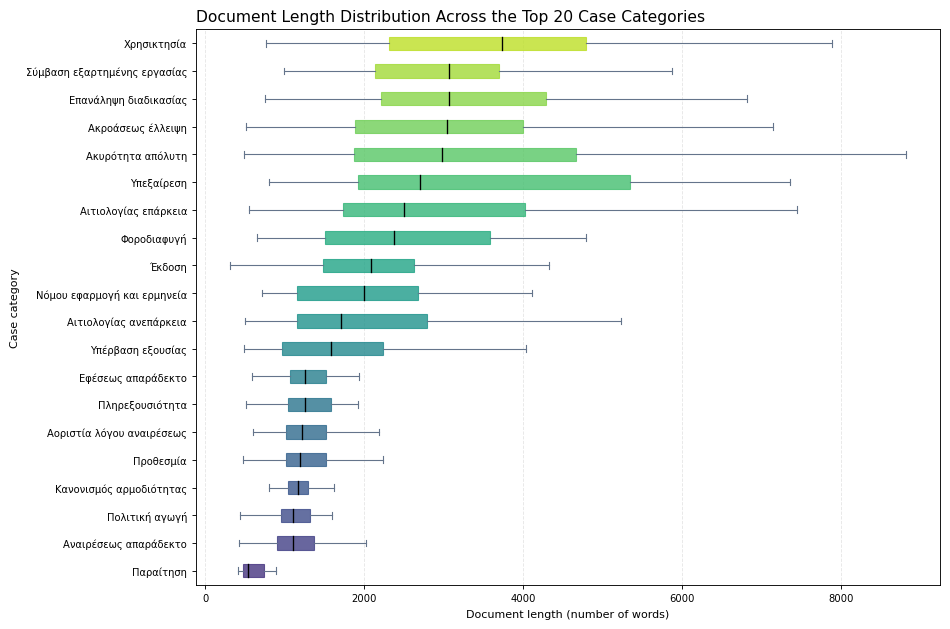

In [12]:
scale = 0.8

# Calculate document length
eda_df = df.dropna(subset=["text", "case_category"]).copy()
# adding doc length
eda_df["document_length"] = eda_df["text"].str.split().str.len()

#  top 20 most frequent categories
top_categories = (eda_df["case_category"].value_counts().head(20).index)

plot_df = eda_df[eda_df["case_category"].isin(top_categories)].copy()

# Order the selected categories by median document length
category_order = (plot_df.groupby("case_category")["document_length"].median().sort_values().index)

# Numeric observations for each box
boxplot_data = [plot_df.loc[plot_df["case_category"] == category,"document_length"].values for category in category_order]

fig, ax = plt.subplots(figsize=(12 * scale, 8 * scale))
colors = colormaps["viridis"](np.linspace(0.15, 0.9, len(boxplot_data)))

boxplot = ax.boxplot(
    boxplot_data,
    labels=category_order,
    vert=False,
    patch_artist=True,
    showfliers=False,
    widths=0.6 * scale,
    boxprops={"linewidth": 1 * scale},
    medianprops={
        "color": "black",
        "linewidth": 1.2 * scale
    },
    whiskerprops={
        "color": "#64748B",
        "linewidth": 1 * scale
    },
    capprops={
        "color": "#64748B",
        "linewidth": 1 * scale
    }
)

for box, color in zip(boxplot["boxes"], colors):
    box.set_facecolor(color)
    box.set_edgecolor(color)
    box.set_alpha(0.8)

ax.set_title(
    "Document Length Distribution Across the Top 20 Case Categories",
    fontsize=14 * scale,
    loc="left"
)

ax.set_xlabel(
    "Document length (number of words)",
    fontsize=10 * scale
)

ax.set_ylabel(
    "Case category",
    fontsize=10 * scale
)

ax.tick_params(
    axis="both",
    labelsize=9 * scale,
    width=0.8 * scale,
    length=3.5 * scale
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8 * scale,
    alpha=0.3
)

for spine in ax.spines.values():
    spine.set_linewidth(0.8 * scale)

plt.tight_layout()
plt.show()

It would be useful to study the relationship between case_category and case_tags. It is obvious that the category case_category is a part of case_tags set. But it's presence in the set doesn't guarantee that it will selected as the overall description for the category. This selection rate is measured and illustrated using bar chart.

In [13]:
# --------------------------------------------------
# 1. Preparing  data
# --------------------------------------------------

data = df.dropna(
    subset=["case_category", "case_tags"]
).copy()

data["case_category"] = (
    data["case_category"]
    .astype(str)
    .str.strip()
)


def parse_tags(value):
    if isinstance(value, (list, tuple, set)):
        tags = value
    else:
        tags = str(value).split(",")

    return [
        str(tag).strip()
        for tag in tags
        if str(tag).strip()
    ]


data["tags_list"] = data["case_tags"].apply(parse_tags)


# --------------------------------------------------
# 2. Extract the 20 most frequent category titles
# --------------------------------------------------

top_titles = (
    data["case_category"]
    .value_counts()
    .head(20)
    .index
)


# --------------------------------------------------
# 3. Calculate selection probability
# --------------------------------------------------

results = []

for title in top_titles:

    # Documents where the title appears in case_tags
    title_is_available = data["tags_list"].apply(
        lambda tags: title in tags
    )

    available_count = title_is_available.sum()

    # Documents where it appears and is selected
    title_is_selected = (
        title_is_available
        & data["case_category"].eq(title)
    )

    selected_count = title_is_selected.sum()

    probability = (
        selected_count / available_count
        if available_count > 0
        else 0
    )

    results.append({
        "title": title,
        "available_count": available_count,
        "selected_count": selected_count,
        "selection_probability": probability
    })


selection_stats = pd.DataFrame(results)

selection_stats["not_selected_probability"] = (
    1 - selection_stats["selection_probability"]
)

# Order titles by selection probability
selection_stats = selection_stats.sort_values(
    "selection_probability"
).reset_index(drop=True)

# checking the df
# selection_stats

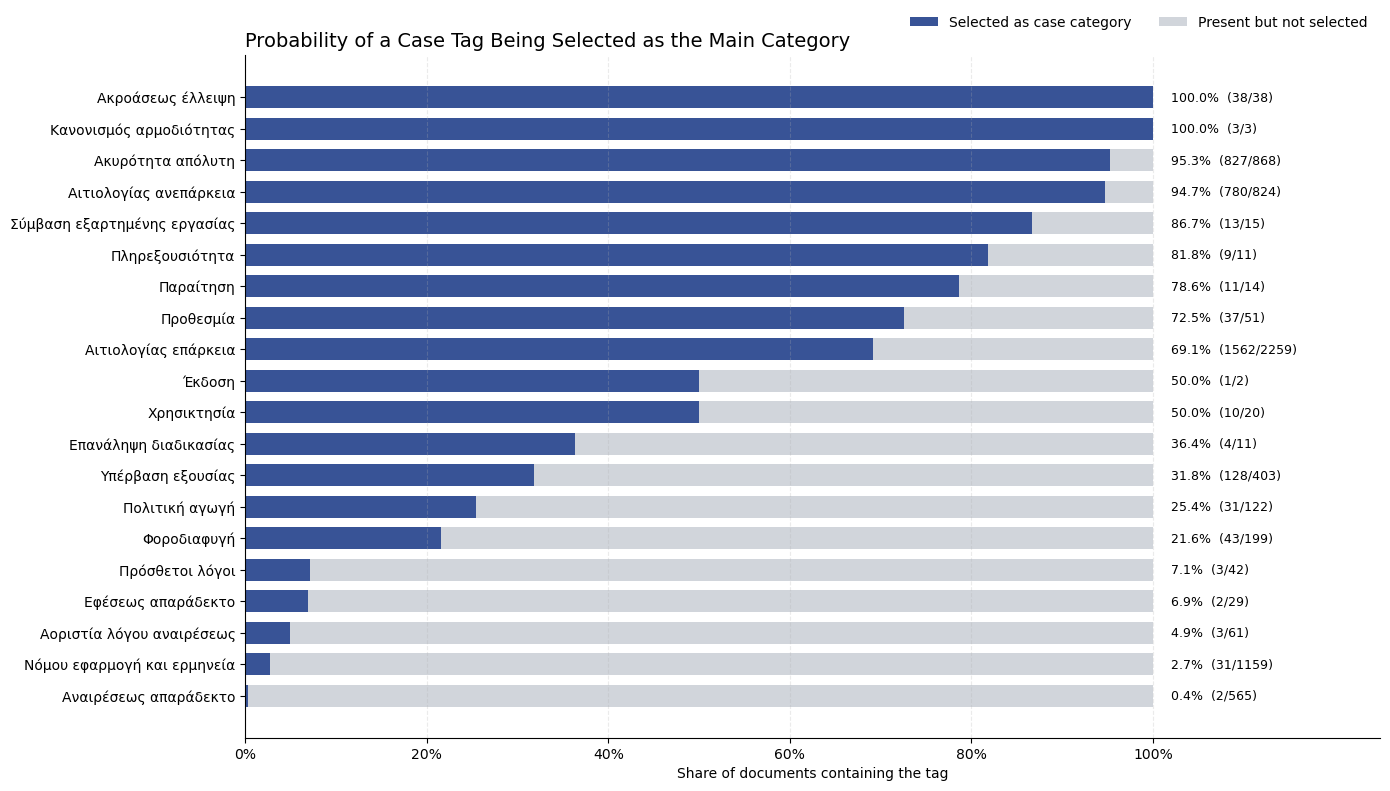

In [14]:
fig, ax = plt.subplots(figsize=(14, 8))

y_positions = np.arange(len(selection_stats))

# Selected as case_category
ax.barh(
    y_positions,
    selection_stats["selection_probability"],
    color="#385396", 
    height=0.7,
    label="Selected as case category"
)
# Present in case_tags but not selected
ax.barh(
    y_positions,
    selection_stats["not_selected_probability"],
    left=selection_stats["selection_probability"],
    color="#D1D5DB",
    height=0.7,
    label="Present but not selected"
)

# Probability and count annotations
for y, row in selection_stats.iterrows():
    ax.text(
        1.02,
        y,
        (
            f"{row['selection_probability']:.1%}  "
            f"({int(row['selected_count'])}/"
            f"{int(row['available_count'])})"
        ),
        va="center",
        fontsize=9
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(selection_stats["title"])

#  space for annotations
ax.set_xlim(0, 1.25)
ax.set_xticks(np.linspace(0, 1, 6))
ax.xaxis.set_major_formatter(PercentFormatter(1))

ax.set_title(
    "Probability of a Case Tag Being Selected as the Main Category",
    fontsize=14,
    loc="left"
)

ax.set_xlabel("Share of documents containing the tag")
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower right",
    bbox_to_anchor=(1, 1.02),
    ncol=2,
    frameon=False
)
plt.tight_layout()
plt.show()

Observation for clustering: A cluster may be better characterized by a combination of related tags rather than a single case_category. Although one tag is selected as the main category, it may not adequately represent the document’s complete thematic content, particularly when that tag is rarely chosen as the primary label.

### Dense Embeddings and Training Word2Vec Model

Choice of Dense embeddings: Given the previous dense model analysis and vectorization techniques, the optimal choice is to train Word2Vec on current dataset combined with mean pooling technique.

In [15]:
class SentenceCorpus:
    def __init__(self, texts):
        self.texts = texts

    def __iter__(self):
        for text in self.texts:
            # check if text exists
            if not isinstance(text, str):
                continue

            # start_time = time.perf_counter()


            for sentence in sent_tokenize(text):
                tokens = [word.lower() for word in word_tokenize(sentence) if word.strip()]

                if tokens:
                    yield tokens

            # print(time.perf_counter() - start_time)

In [16]:
def train_word2vec(text):
    corpus = SentenceCorpus(df[text])
    
    model = Word2Vec(
        vector_size=300,
        window=5,
        min_count=2,
        workers=4,
        sg=0
    )
    
    # 1st pass: building vocabulary
    model.build_vocab(corpus)
    
    # 2nd pass: train
    model.train(
        corpus,
        total_examples=model.corpus_count,
        epochs=model.epochs
    )
    return model

In [17]:
def dense_embed_text(text, model):
    words = text.lower().split()
    vectors_model = model.wv
    
    word_vectors = [
        vectors_model[word]
        for word in words
        if word in vectors_model
    ]

    if not word_vectors:
        return np.zeros(vectors_model.vector_size)

    return np.mean(word_vectors, axis=0)


In [18]:
def build_embedding_dataset(model, text):
    # dense embed each word in summary
    embedded_text = np.vstack(df[text].apply(lambda x: dense_embed_text(x, model)))
    return embedded_text

def encode_target(target):
    # encode case_category
    label_encoder = LabelEncoder()
    target = label_encoder.fit_transform(df[target])
    return target 

### Unsupervised Learning: K-means Clustering

For this dataset, clustering will be tested with 2 columns, text and summary, as they both contain text, that can be represented using vecotrs, and potentially form groups/clusters  which could provide more insights about different thematic groups.

Assumptions: as cluster form using distances between vectors, and those distances for texts of similar meaning should be close to each other (due to word2vec embedding)

Potential challenges: 2 core issues here, first is that there are 400 unique categories in case category, which could potentially lead to bad cluster separation. and the second being that the case_category is too strict in meaning, potentially a text is better described using a varitey of tags, as in case tags.

In [19]:
# silhouette : returns a value in the range [-1, 1], where:

# +1: Points are well-clustered, far from neighboring clusters.
# 0 : Points lie on the boundary between clusters.
# -1: Points are likely assigned to the wrong cluster.

In [20]:
from sklearn.preprocessing import normalize

def kmeans(X,Y):

    silhouette_scores = []
    nmi_scores = []
    
    for k in range(5,101,5):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        X = normalize(X)
        cluster_labels = km.fit_predict(X)
        nmi = normalized_mutual_info_score(Y, cluster_labels)
        nmi_scores.append(nmi)
        silhouette = silhouette_score(X, cluster_labels)
        silhouette_scores.append(silhouette)
        # print(f"for k={k}, Silhouette score is = {silhouette:.4f}")
        # print(f"for k={k}, NMI is ={nmi:.4f}")
    return silhouette_scores, nmi_scores

Clustering for `text` column

In [21]:
model =  train_word2vec("text")

embedded_text = build_embedding_dataset(model, "text")

target = encode_target("case_category")

In [22]:
silhouette_scores, nmi_scores = kmeans(embedded_text, target)

In [23]:

def plot_scores(silhouette_scores, nmi_scores):
    k_values = list(range(5, 101, 5))
    
    # finding the best k 
    best_k_nmi = k_values[np.argmax(nmi_scores)]
    best_k_silhouette = k_values[np.argmax(silhouette_scores)]
    
    # 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # NMI plot
    axes[0].plot(k_values, nmi_scores, marker="o", color="#4F46E5")
    
    axes[0].axvline(best_k_nmi,linestyle="--",color="#DC2626",label=f"Best at k = {best_k_nmi}")
    
    axes[0].set_xlabel("Number of clusters (k)")
    axes[0].set_ylabel("NMI Score")
    axes[0].set_title("NMI vs. Number of Clusters")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # silhouette plot
    axes[1].plot(k_values, silhouette_scores, marker="o", color="#059669")
    
    axes[1].axvline(best_k_silhouette, linestyle="--",color="#DC2626", label=f"Best at k = {best_k_silhouette}")
    
    axes[1].set_xlabel("Number of clusters (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].set_title("Silhouette Score vs. Number of Clusters")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

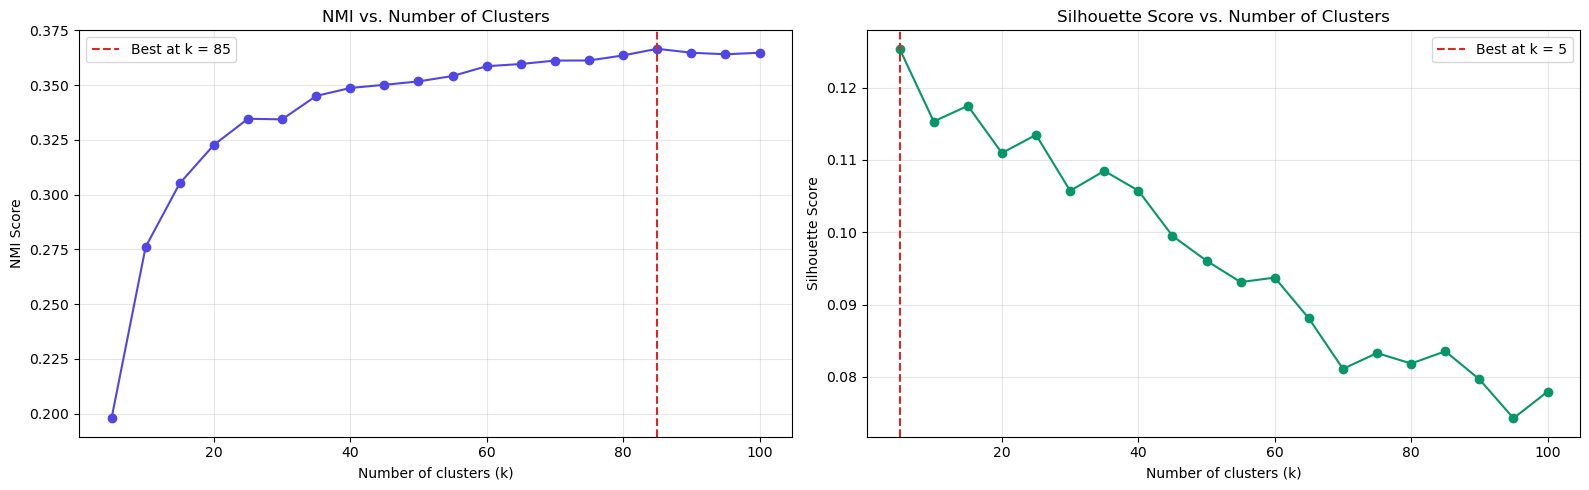

In [24]:
plot_scores(silhouette_scores, nmi_scores)

Clustering for `summary` column

In [25]:
model =  train_word2vec("summary")

embedded_text = build_embedding_dataset(model, "summary")

target = encode_target("case_category")

In [26]:
silhouette_scores_summary, nmi_scores_summary = kmeans(embedded_text, target)

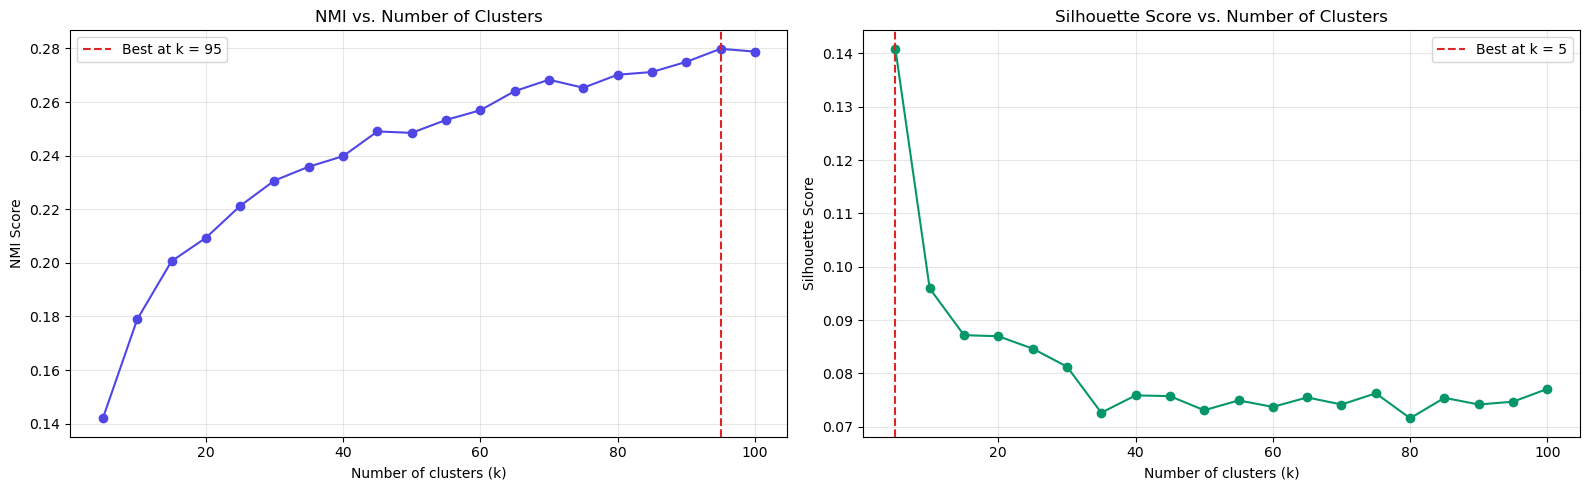

In [27]:
plot_scores(silhouette_scores_summary, nmi_scores_summary)

#### Clustering Performance #### 

Overall both attempts of clustering, with full-text and summary representations produced poor scores (NMI and silhouette) and thus produced weakly separated clusters.

For the full text, the silhouette score reaches its maximum of approximately 0.12 at k=5 and gradually decreases as more clusters are introduced. The summary representation follows a similar pattern: its silhouette score peaks at approximately 0.14 for k=5, drops sharply, and remains around 0.07–0.08 for most larger values of k. These consistently low values indicate substantial overlap between clusters and suggest that the documents do not form compact, clearly separated thematic groups in the embedding space.

However, silhouette illustrates that as the number of clusters increases, their quality (cohesion and separation) decreases. This is also true, as with more separation, each point is more likely to exist between small clusters. Choosing a very small number e.g k=5 could be unreasonable since there are 399 unique labels that describe documents thematic meanings.

NMI increases, as the cluster number increases, reaching approximately 0.37 for the full text and 0.28 for the summaries. This trend is expected and nmi will increase  as k grows, since with almost 400 unique labels finer partitions are more likely to align with some of the 399 category labels. In general, full-text representation shows stronger agreement with case_category, while the summaries provide less information for reproducing the assigned labels.


#### Choice of K ####

EDA showed that 33 of the 399 categories account for 80% of the documents. Although this does not imply that the data contain exactly 33 natural clusters, it suggests that most documents are concentrated around a substantially smaller number of dominant themes. Therefore, k=25 is selected as a pragmatic exploratory compromise: it allows considerably more thematic detail than k=5 while avoiding the extensive fragmentation and declining cohesion observed at larger values of k.


#### Improving K-means Clustering Results ####

K-means clusters documents using Euclidean distance, which can be influenced by vector magnitude. Therefore, mean-pooled document embeddings should be L2-normalized before clustering, making Euclidean distance reflect cosine similarity and not magnitude.

In [38]:
from sklearn import preprocessing
from sklearn.decomposition import PCA
# L2 normaliztionh to remove magnitude
# embedded_text is np array
normalized_data_l2 = preprocessing.normalize(embedded_text, norm='l2')

# # 2. Reduce dimensionality
# pca = PCA(n_components=100, random_state=42)
# X_reduced = pca.fit_transform(normalized_data_l2)

# # 3. Normalize the reduced embeddings
# X_norm = normalize(X_reduced, norm="l2")


In [39]:
silhouette_scores_l2, nmi_scores_l2 = kmeans(normalized_data_l2, target)

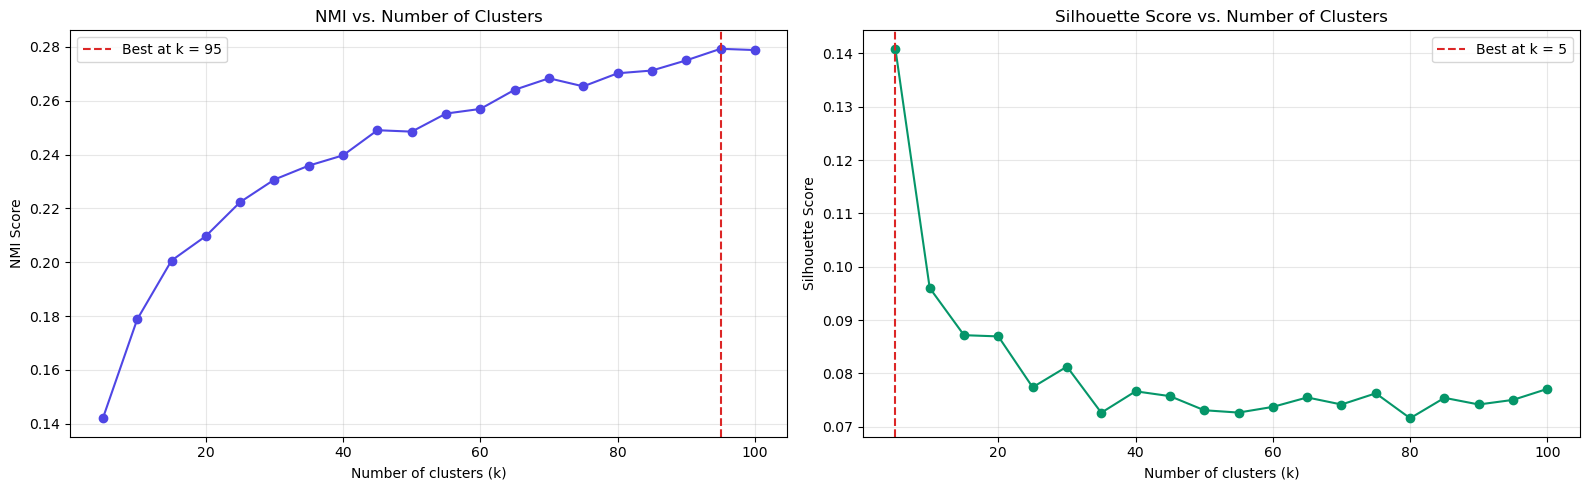

In [40]:
plot_scores(silhouette_scores_l2, nmi_scores_l2)

### HDBSCAN Clustering

c-TF–IDF is calculated after clustering. It identifies the words that distinguish each entire cluster from the other clusters. It explains the topics but does not determine cluster membership.

In [ ]:
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from bertopic import BERTopic

# Load a custom embedding model
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Configure HDBSCAN with specific parameters
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom')

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=42)

# Pass it into BERTopic
vectorizer_model = CountVectorizer(min_df=2, ngram_range=(1, 2))# Extracts both unigrams and bigrams 

# bertopic pipeline
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)

# get assigned groups/ probabilities
topics, probs = topic_model.fit_transform(["summary"].tolist())

topic_info = topic_model.get_topic_info()

display(
    topic_info[
        ["Topic", "Count", "Name", "Representation"]
    ]
)